<a href="https://colab.research.google.com/github/stivenjosez/Analisis-Novaretail-/blob/main/S8_Student_Version_Project_NovaRetail_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
from scipy.stats import chi2_contingency, pointbiserialr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `gasto_publicidad_dirigida`
- `visitas_mes`
- `compras_mes`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` presenta datos en decimales lo cula es incorrecto y se deberia convertir a enteros


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` muestra un range de edades de los usarios desde los 18 hasta los 75 años.
- `nivel_ingreso` se logra ver que la mediana y media tiene casi exactamente el mismo valor lo que demuestra que los valores no presentan outlaider o valores atipicos entre si.
- `visitas_mes` tiene un range de visitas de entre 1 a 25 con un promedio de visitas de 10 por mes.
- `compras_mes` tiene una mediana de 1 y una media de 1.2 lo que sujiere que la mayoria de los usuario realizan pocas compras al mes.
- `gasto_publicidad_dirigida` Posee un promedio de 20.15, con valores que van desde 0 hasta un máximo de 75.51.
- `satisfaccion` El nivel promedio de satisfacción se sitúa en 3.60 sobre una escala de 1 a 5.
- `miembro premium` Al tratarse de una variable binaria, la media de 0.139 indica que aproximadamente el 13.9% de los 15,000 registros corresponden a miembros premium.
- `abandono` Al tratarse de una variable binaria, la media de 0.1507 indica que aproximadamente el 15.07% de los 15,000 registros corresponden a casos de abandono. Su desviación estándar es de 0.3578,
- `ingreso_anual` ingreso_anual — Presenta un valor promedio de 36.59 (con una desviación estándar de 34.48), un valor mínimo de 0 y un máximo de 244.69. La mediana (percentil 50%) se sitúa en 58.22, lo que refleja una distribución con un sesgo hacia valores de ingresos más elevados.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ['miembro_premium','abandono']

for col in columnas_binarias:
    print(f"Valores únicos de '{col}':", df[col].unique())

Valores únicos de 'miembro_premium': [0 1]
Valores únicos de 'abandono': [0 1]


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — cuanto con dos unicos valores, siendo 1 y 0.
- `abandono` —  al igual que la columna miembro_premium, solo cuenta con dos unicos valores para la confimacion de columna binaria.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ['tipo_dispositivo', 'region']

for col in columnas_categoricas:
    print(f"Valores únicos de '{col}':", df[col].unique())

Valores únicos de 'tipo_dispositivo': ['móvil' 'tablet' 'escritorio']
Valores únicos de 'region': ['norte' 'sur' 'este' 'oeste']


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
for col in columnas_categoricas:
    print(f"--- Distribución de '{col}' ---")
    print(df[col].value_counts(normalize=True) * 100) # Muestra el porcentaje (%)
    print("\n")

--- Distribución de 'tipo_dispositivo' ---
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64


--- Distribución de 'region' ---
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64




✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` —  los usuarios de móvil dominan la categoria de tipo de dispositivo con mas del 65% de los usuarios.
- `region` Presenta una distribucion muy simetrica entre regiones, siendo la mas alta norte con 29% y la mas baja este con un 20% aproximadamente.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

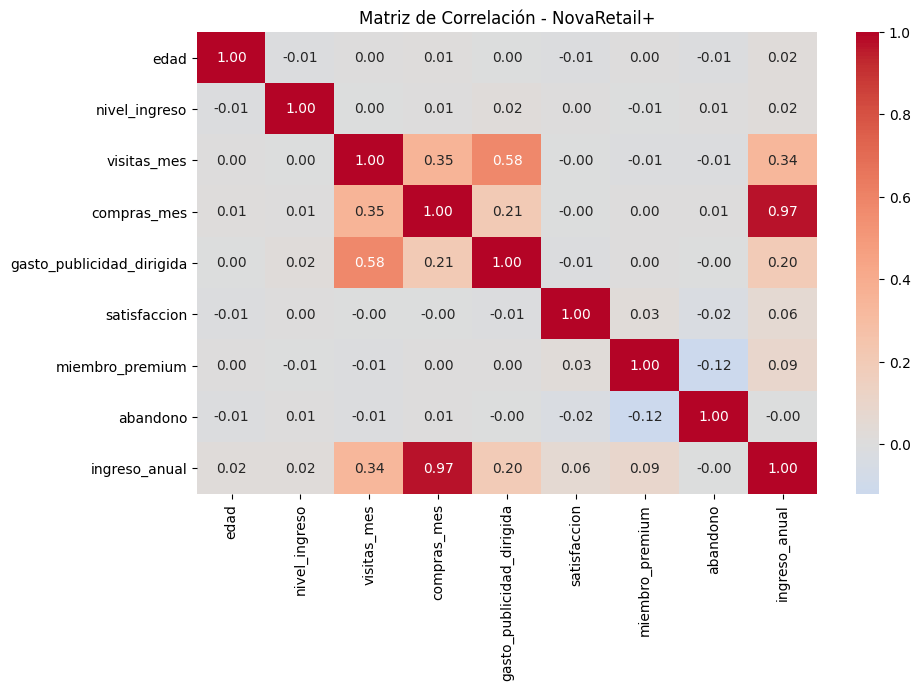

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Matriz de Correlación - NovaRetail+')
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa poca correlacion entre la mayorias de las columnas en el heatmap, variables como edad, nivel de ingreso, satisfaccion, miembro premium y abandono su coeficiente de correlacion es 0 o casi cero, lo que indica que no hay correlacion entre esas columnas.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlacion muy obvia pero que no dice nada, que es con la categoria de compras debido que se supone que entre mas compras mas seria los ingresos anuales.
- Presenta una correlacion positiva con la columnas visitas mes, lo que supone que entre mas visitar lo usuarios tienden a compras mas lo que implica aumento de ingresos.
- Presenta un correlacion positiva leve, comparalandola con la columna de gasto publicidad dirigida.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

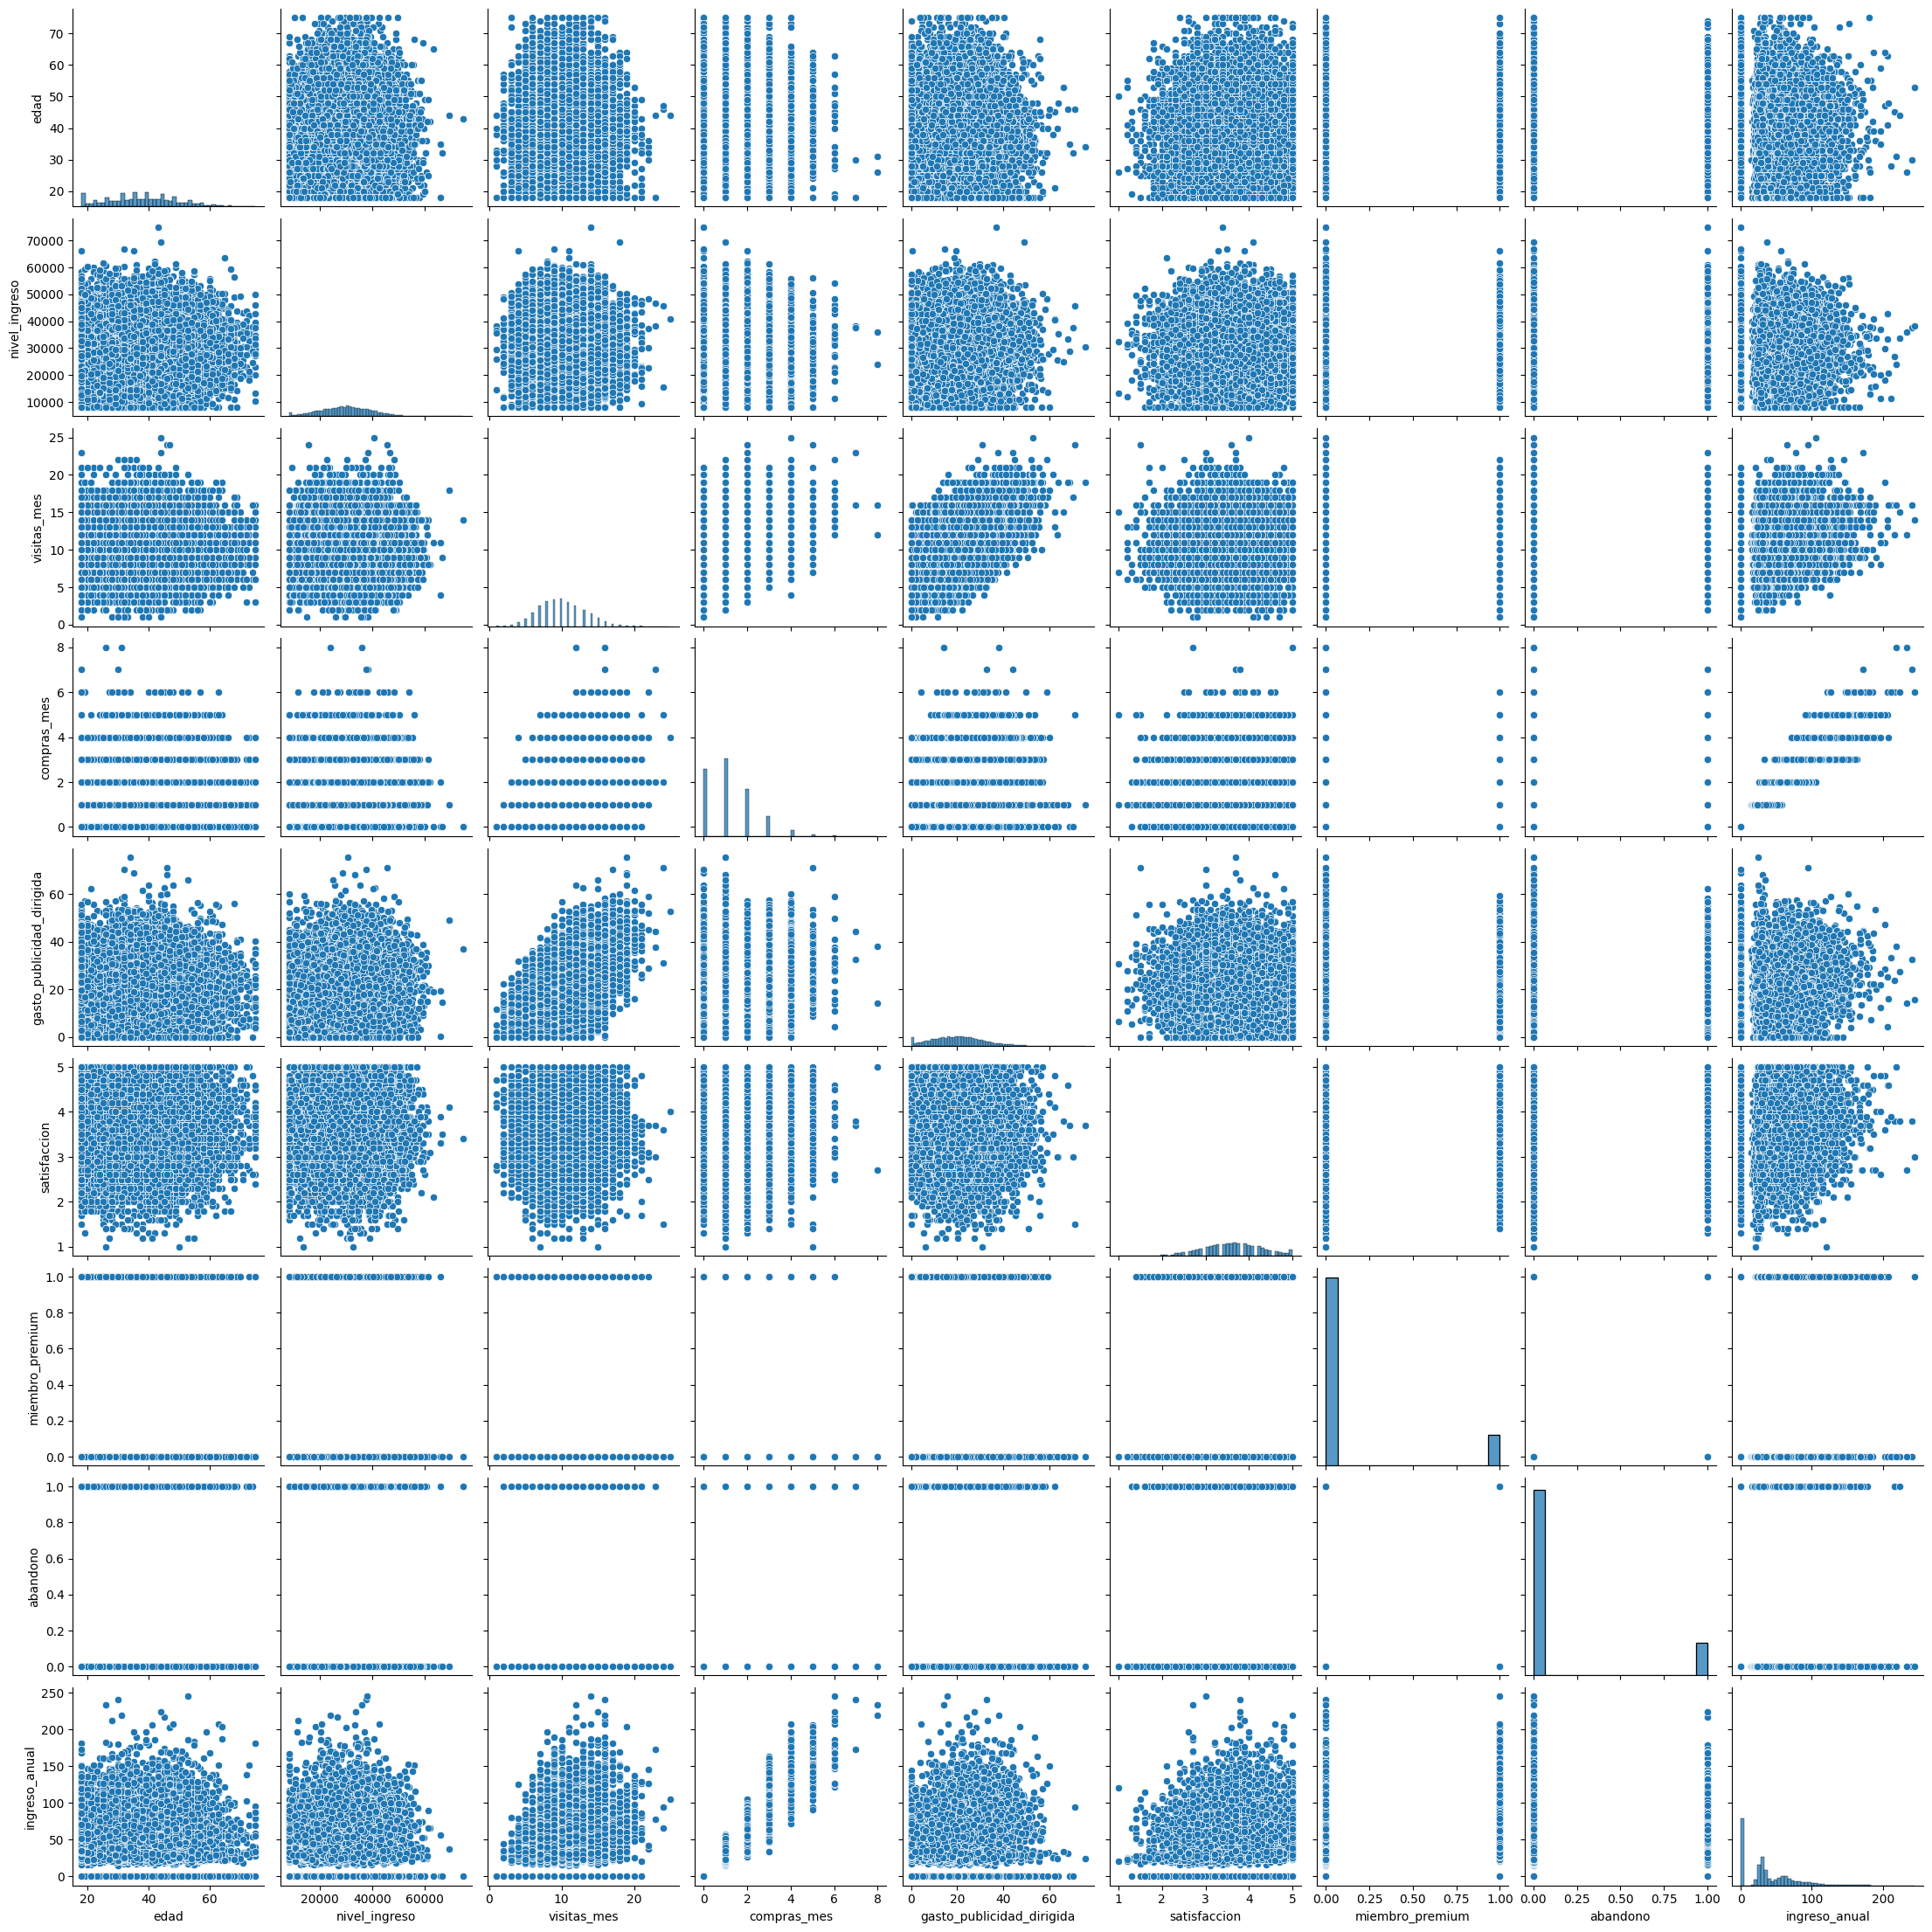

In [ ]:
sns.pairplot(df)

### Scatterplot para pares clave

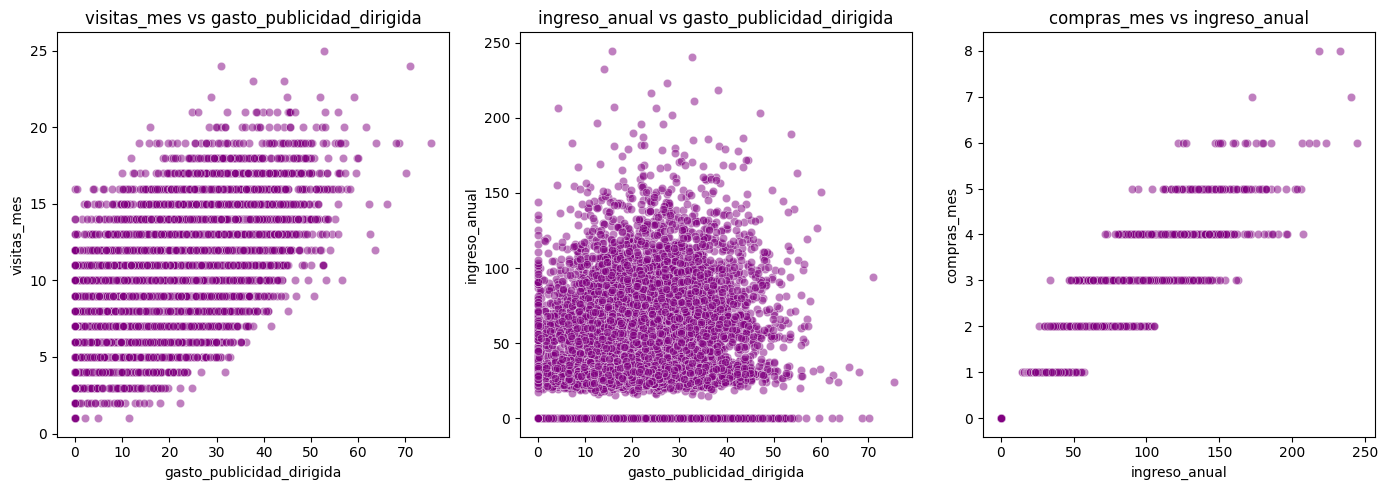

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
pares_clave = [
    ('gasto_publicidad_dirigida', 'visitas_mes'),
    ('gasto_publicidad_dirigida', 'ingreso_anual'),
    ('ingreso_anual','compras_mes')
]

fig, axes = plt.subplots(1, len(pares_clave), figsize=(14, 5))

for i, (x_col, y_col) in enumerate(pares_clave):
    sns.scatterplot(data=df, x=x_col, y=y_col, ax=axes[i], alpha=0.5, color='purple')
    axes[i].set_title(f'{y_col} vs {x_col}')
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)

plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**var1 vs var2**
- Se observa una dirección positiva moderada-fuerte, donde a mayor inversión en publicidad dirigida, tiende a incrementarse la cantidad de visitas mensuales. La dispersión es media, con una concentración uniforme de los datos y algunos valores atípicos (outliers) en los niveles superiores de gasto.
  

**var1 vs var3**
- Muestra una dirección débil o neutral con una dispersión alta. Los datos se acumulan fuertemente en los rangos inferiores de ingreso, evidenciando que un mayor gasto publicitario no garantiza de forma directa un incremento proporcional en el ingreso anual a nivel general, detectándose múltiples outliers hacia los ingresos superiores de 150 a 250.

**var3 vs var4**
- Se logra ver unca direccion positiva fuerte, con una dispersion baja, donde a mayor la cantidad de compras por usuario mayor los ingresos anuales.La dispersión horizontal muestra que, dentro de un mismo rango de ingresos, existe variedad en el comportamiento transaccional de los usuarios.


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
corr_pearson = df['gasto_publicidad_dirigida'].corr(df['visitas_mes'],method='pearson')
corr_spearman = df['gasto_publicidad_dirigida'].corr(df['visitas_mes'], method='spearman')

print("correlacion pearson:", corr_pearson)
print("correlacion spearman:", corr_spearman)

correlacion pearson: 0.5789472719412827
correlacion spearman: 0.5592673242622609


In [ ]:
# Calcular correlación entre variables relevantes

corr_pearson = df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'],method='pearson')
corr_spearman = df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'], method='spearman')

print("correlacion pearson:", corr_pearson)
print("correlacion spearman:", corr_spearman)


correlacion pearson: 0.1974827018234103
correlacion spearman: 0.18499874477115502


In [ ]:
corr_pearson = df['compras_mes'].corr(df['ingreso_anual'],method='pearson')
corr_spearman = df['compras_mes'].corr(df['ingreso_anual'], method='spearman')

print("correlacion pearson:", corr_pearson)
print("correlacion spearman:", corr_spearman)

correlacion pearson: 0.9671485435708564
correlacion spearman: 0.967482492032673


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**var1 vs var2**
- Correlación: Presenta una dirección positiva con una magnitud moderada (Pearson de 0.58 y Spearman de 0.56). Esto indica que a mayor inversión en publicidad dirigida, existe una tendencia clara y consistente a incrementar las visitas mensuales.
-  Colinealidad: No representa un problema de colinealidad severa, ya que el valor se encuentra en un nivel moderado que permite conservar ambas variables de manera independiente en un modelo analítico.

**var2 vs var3**
- Correlación: Muestra una dirección positiva pero con una magnitud muy débil (Pearson de 0.20 y Spearman de 0.18). Esto refleja que la relación lineal entre el gasto publicitario y el ingreso anual de los usuarios es escasa.
- Colinealidad: Al ser una correlación baja, se descarta por completo cualquier riesgo de colinealidad o redundancia entre estas dos métricas.

**var3 vs var4**
- Correlación: Presenta una dirección positiva con una magnitud muy fuerte (Pearson de 0.97 y Spearman de 0.97). Esto indica que a mayor nivel de ingresos anuales de los usuarios, existe una tendencia directa, lineal y sumamente consistente a incrementar la cantidad de compras mensuales.
- Colinealidad: Representa un nivel de correlación muy elevado, por lo que sí sugiere la presencia de colinealidad fuerte o redundancia informativa entre ambas variables.  

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
print(pointbiserialr(df['miembro_premium'], df['ingreso_anual']))
print(pointbiserialr(df['abandono'], df['ingreso_anual']))

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)
SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**var1 vs var2**
- Relación positiva aunque casi nula, lo que indica que no hay correlacion entre ambas columnas

**var2 vs var3**
- Relación positiva o neotral, la correlacion es practicamente 0 lo que indica que no existe correlacion entre ambas categorias.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
tabla = pd.crosstab(df['tipo_dispositivo'], df['region'])
chi2, p, dof, expected = chi2_contingency(tabla)

n = tabla.sum().sum()
creamer_v = np.sqrt(chi2/(n*(min(tabla.shape)-1)))

In [ ]:
# Aplicar V de Cramér en variables relevantes
creamer_v

0.012378338407739397

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér - Esto demuestra que la elección del tipo de dispositivo no está relacionada ni depende de la región geográfica de los usuarios; ambas variables se comportan de manera independiente dentro del conjunto de datos.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 —

**Evidencia visual:**   Gráfico de dispersión (scatterplot) que cruza gasto_publicidad_dirigida frente a visitas_mes

**Evidencia numérica:** Coeficiente de correlación de Pearson de 0.5879 y de Spearman de 0.5593.

**Interpretación**  
Existe una tendencia positiva moderada; a mayor inversión en publicidad dirigida, se registra consistentemente un mayor volumen de visitas mensuales por parte de los usuarios.

**No podemos afirmar**  
Que el aumento del gasto publicitario sea la causa directa y única del incremento de tráfico, ya que la correlación estadística no demuestra causalidad absoluta.

**Implicación de negocio**  
La inversión en publicidad dirigida está alineada con una mayor actividad de los usuarios en la plataforma, lo que avala la continuidad y optimización de estas campañas para estimular el tráfico y la interacción.

### Hallazgo 2 —

**Evidencia visual:**  Gráfico de dispersión (scatterplot) que cruza ingreso_anual frente a gasto_publicidad_dirigida, mostrando una nube de puntos altamente dispersa y sin una tendencia lineal definida.

**Evidencia numérica:** Coeficiente de correlación de Pearson de 0.1975 y de Spearman de 0.1850.

**Interpretación**  
Existe una relación positiva extremadamente débil o nula entre el presupuesto destinado a la publicidad dirigida y el nivel de ingresos anuales de los usuarios.

**No podemos afirmar**  
Que incrementar la inversión en publicidad dirigida vaya a generar un aumento directo o proporcional en el ingreso anual de los clientes.

**Implicación de negocio**  
Asignar más presupuesto publicitario a los usuarios basándose únicamente en su nivel de ingresos actual no es una estrategia eficiente; se sugiere revisar la segmentación de las campañas para enfocarlas en métricas de comportamiento (como visitas o interacción) en lugar del poder adquisitivo.

### Hallazgo 3 —

**Evidencia numérica:** Coeficiente V de Cramér de 0.0124.

**Interpretación**  Existe una asociación nula o extremadamente débil entre el tipo de dispositivo y la región geográfica de los usuarios.

**No podemos afirmar**  
Que la región de residencia del usuario condicione o determine de forma significativa el tipo de dispositivo que utiliza para interactuar con la plataforma.

**Implicación de negocio**  
la correlacion entre las variables y tipos de dispositivo . Esto significa que las estrategias comerciales o tecnológicas orientadas a dispositivos específicos no necesitan fragmentarse o ajustarse por regiones geográficas basándose en este comportamiento.

### Hallazgo 4 —

**Evidencia visual** Gráfico de dispersión (scatterplot) que cruza compras_mes frente a ingreso_anual, mostrando un claro patrón de progresión positiva con bandas escalonadas debido a la naturaleza discreta de las compras.

**Evidencia numérica:** Coeficiente de correlación de Pearson de 0.9671 y de Spearman de 0.9675.

**Interpretación**  Existe una relación positiva muy fuerte y directa entre el nivel de ingresos anuales de los usuarios y su volumen de compras mensuales; a mayor ingreso, se incrementa de manera consistente la cantidad de transacciones realizadas.

**No podemos afirmar**  
Que un incremento en los ingresos del usuario provoque por sí solo y de forma automática la realización de más compras, ya que la correlación indica asociación y no una causalidad absoluta.

**Implicación de negocio**  
El ingreso anual es un indicador clave del comportamiento transaccional, lo que permite enfocar las estrategias comerciales, de fidelización y de upselling prioritariamente en los segmentos de mayor poder adquisitivo para maximizar el valor de la plataforma.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad Las relaciones estadísticas encontradas (como entre el gasto en publicidad y las visitas mensuales) indican asociación o tendencia, pero no confirman una relación de causa-efecto directa.
  
-Variables omitidas: El alcance del análisis se limita al conjunto de datos actual, sin contemplar factores externos del mercado (como estacionalidad, acciones de la competencia o campañas macroeconómicas) que puedan influir en el comportamiento de los usuarios.

### **Próximos pasos**

Probar segmentación adicional
- Analizar el comportamiento de los usuarios segmentando por rangos de edad y niveles de satisfacción para identificar nichos de alto valor.
- Cruzar la condición de miembro premium con los patrones de compra y frecuencia de visitas mensuales.

Experimentación y validación causal

Diseñar pruebas A/B controladas para medir el impacto real y causal de las variaciones en el presupuesto de publicidad dirigida sobre las conversiones de compra.

Análisis de Cohortes (Cohort Analysis):
- Agrupar a los usuarios según el período en el que se registraron o adquirieron su membresía para evaluar cómo evoluciona su retención y su tasa de abandono (abandono) a lo largo del tiempo.